<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/alba_HeartCycle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [38]:
import os
import pandas as pd
from google.colab import drive
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# mount Google Drive
drive.mount('/content/drive')
dir_path = "/content/drive/MyDrive/Data_HeartCycle/59146237"

# # list files
# files = os.listdir(dir_path)
# print("\nAvailable files:")
# for i, file in enumerate(files):
#     print(f"{i}: {file}")

# # file selection
# file_index = int(input("\nEnter file number: "))
# file_path = os.path.join(dir_path, files[file_index])

file_path = '/content/drive/MyDrive/Data_HeartCycle/59146237/59146237_s0000002.mat'
data_hc = sio.loadmat(file_path)
print(data_hc.keys())

header = data_hc['__header__']
#print(header)
#b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Thu Mar 12 19:36:31 2009'

version = data_hc['__version__']
#print(version)
# 1.0

globals = data_hc['__globals__']
#print(globals)
# []

measures = data_hc['measure']
#print(measures)

print(type(measures))        # ndarray
print(measures.shape)       # 30 rows and 5 columns

rows, cols = measures.shape # measures is a 30x5 ndarray
# to find out how many signals we have
for i in range(rows):
    for j in range(cols):
        try:
            label = measures[i, j]['label'][0, 0]
            print(f"{label} = measures[{i},{j}]")
        except:
            continue

print(measures[1,1]['label'][0]) #ICG

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dict_keys(['__header__', '__version__', '__globals__', 'measure'])
<class 'numpy.ndarray'>
(30, 5)
['Event'] = measures[0,0]
['ECG'] = measures[0,1]
['ECG'] = measures[0,2]
['ECG'] = measures[0,3]
['ECG'] = measures[0,4]
['SPO2'] = measures[1,0]
['IMP'] = measures[1,1]
['PCG'] = measures[1,2]
['ECHO'] = measures[1,3]
['PPG'] = measures[1,4]
['O/C'] = measures[2,0]
['RPEAKS'] = measures[2,1]
['RPEAKS'] = measures[2,2]
['RPEAKS'] = measures[2,3]
['RPEAKS'] = measures[2,4]
['Load'] = measures[3,0]
['AVO'] = measures[3,1]
['AVO'] = measures[3,2]
['AVO'] = measures[3,3]
['AVO'] = measures[3,4]
['HPD'] = measures[4,0]
['PPEjec'] = measures[4,1]
['PEP'] = measures[4,2]
['PEP'] = measures[4,3]
['PEP'] = measures[4,4]
['DC'] = measures[5,0]
['AVC'] = measures[5,1]
['AVC'] = measures[5,2]
['AVC'] = measures[5,3]
['AVC'] = measures[5,4]
['TFC'] = measures[6,0]
['LVET'] 

# ICG + Preprocess

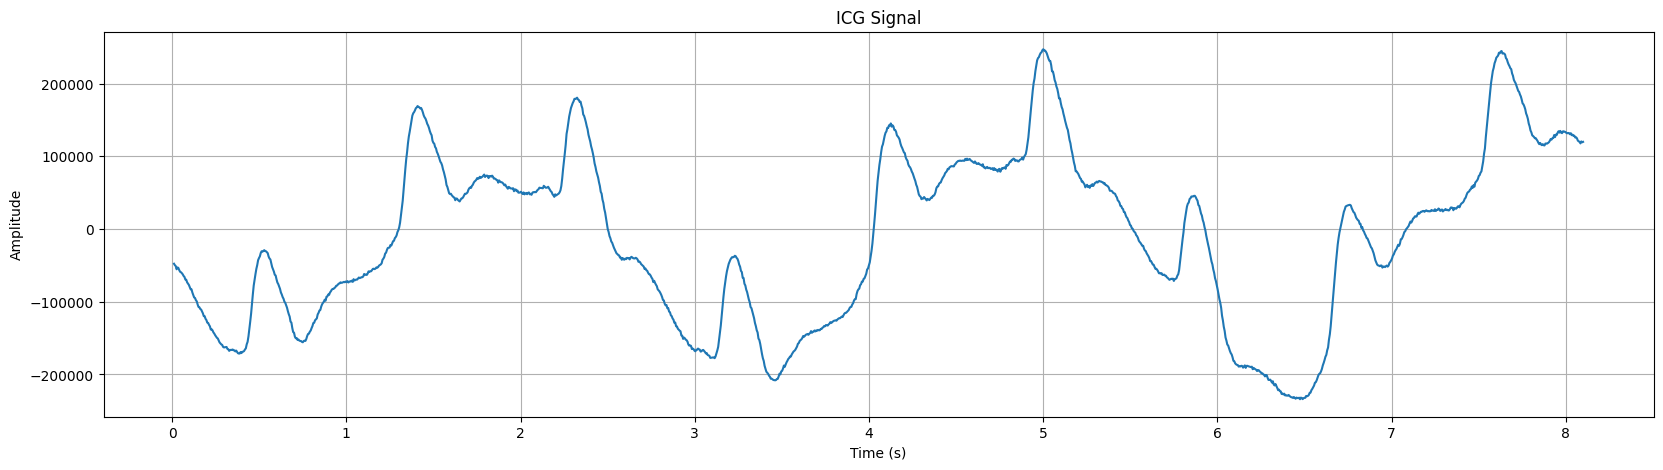

In [39]:
import matplotlib.pyplot as plt

icg = measures[1,1] #extract the ICG signal
icg_time = icg['time'][0,0].flatten()
icg_data = icg['data'][0,0].flatten()

plt.figure(figsize=(20, 5))
plt.plot(icg_time, icg_data)
plt.title('ICG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## ICG Preprocessing
The most important artifacts affecting the ICG signal are sinusoidal, respiratory, muscle, and electrode artifacts [ReBeat]
- Sinusoidal: power line -> band pass
- Respiratory: very low frequency -> band pass with low cutoff 0.5 and also SG filter [ReBeat]
- Muscle: very high frequency -> band pass with high cutoff 20 for example?
- Electrode: bad contact, movement -> wavelet

## Band pass filter

In [40]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

dt = np.mean(np.diff(icg_time))      #time step, we calculate the average interval between consecutive time samples
fs = 1 / dt                          #sampling frequency
print(fs) #198.45387059502093

198.78245073267092


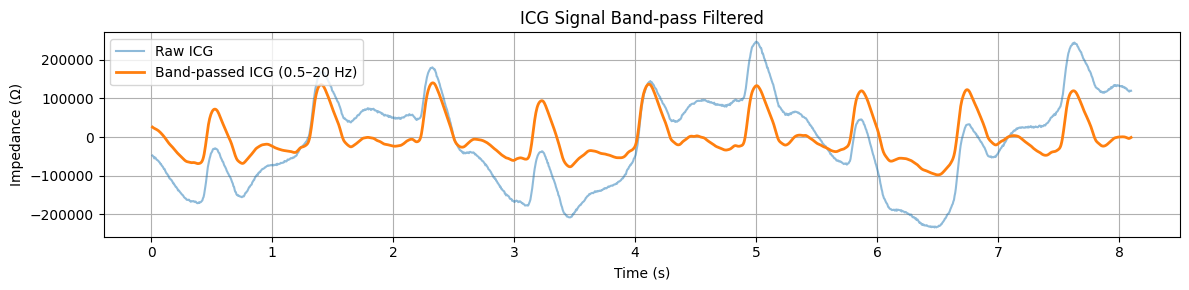

In [41]:
def bandpass(signal, fs, lowcut, highcut, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)
icg_bandpassed = bandpass(icg_data, fs,0.5,20)

plt.figure(figsize=(12, 3))
plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG (0.5–20 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Impedance (Ω)')
plt.title('ICG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Savitzky-Golay filter

If we overlay the bandpassed ICG and the SG ICG we see they overlap, suggesting that SG is not actually helping.
We used SG as a smoothing filter:
- It smooths out high-frequency noise, it preserves local shape, but it may flatten sharp peaks
- We're replacing the signal with a smoothed version

The Savitzky-Golay filter is a smoothing filter based on local polynomial regression. Instead of simply averaging neighboring points (like a moving average does), SG fits a polynomial curve to a small window of the data, and replaces the center point with the value predicted by that polynomial

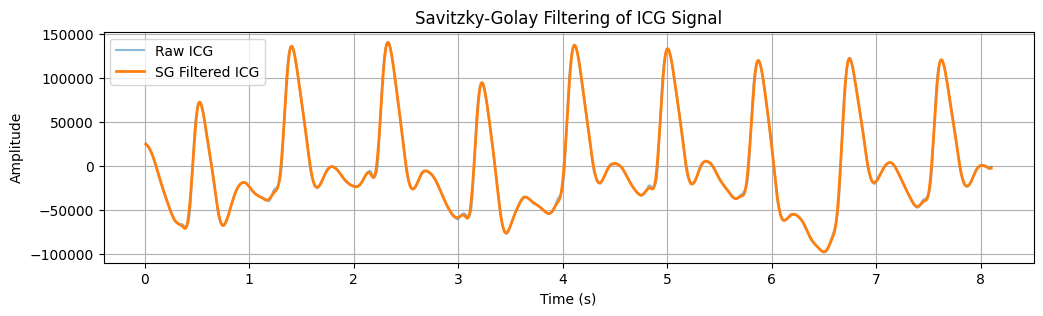

In [42]:
from scipy.signal import savgol_filter

icg_sg = savgol_filter(icg_bandpassed, window_length=31, polyorder=3)

plt.figure(figsize=(12,3))
plt.plot(icg_time, icg_bandpassed, label='Raw ICG', alpha=0.5)
plt.plot(icg_time, icg_sg, label='SG Filtered ICG', linewidth=2)
plt.legend()
plt.title("Savitzky-Golay Filtering of ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

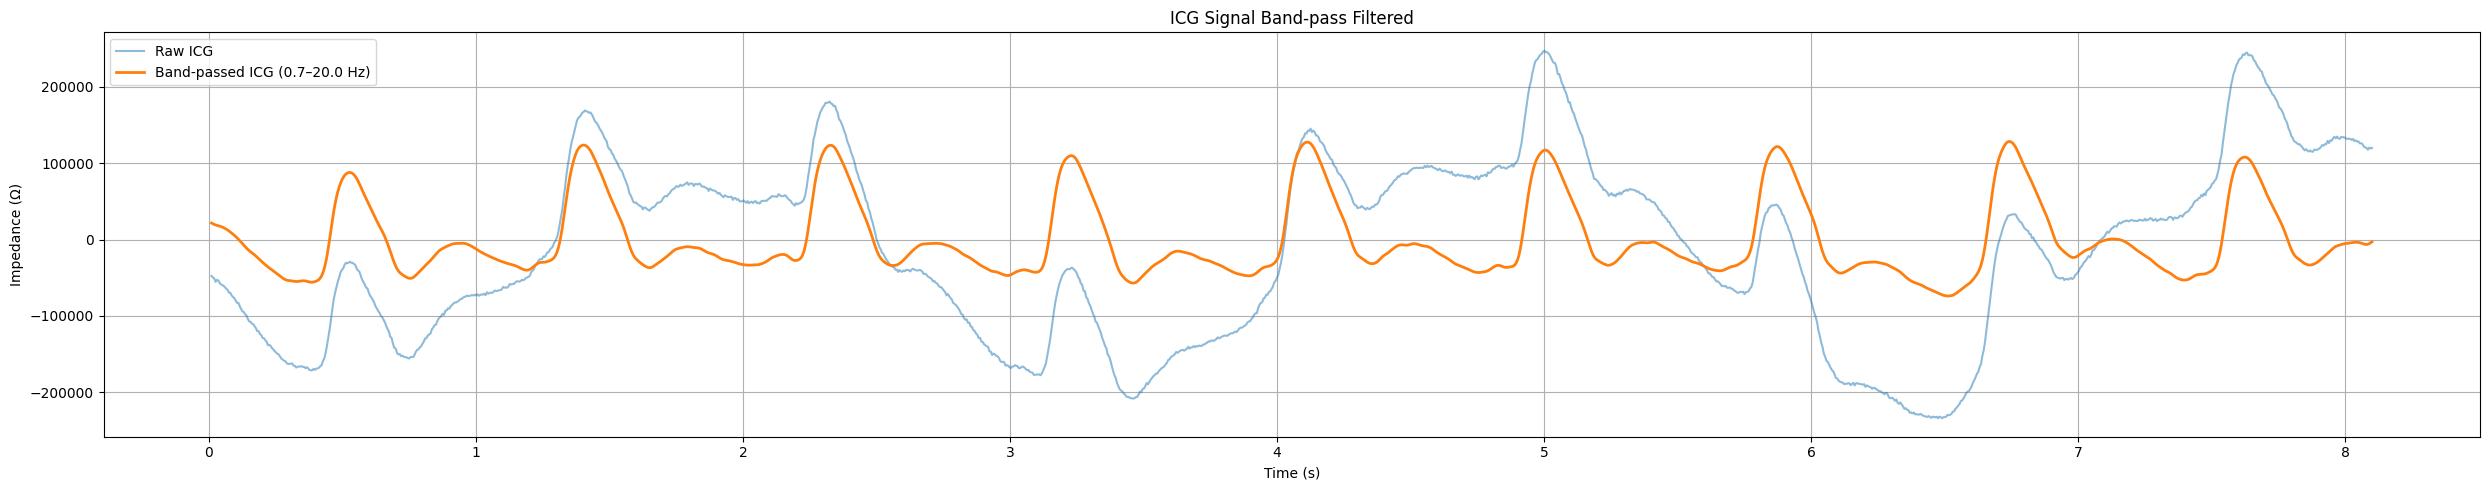

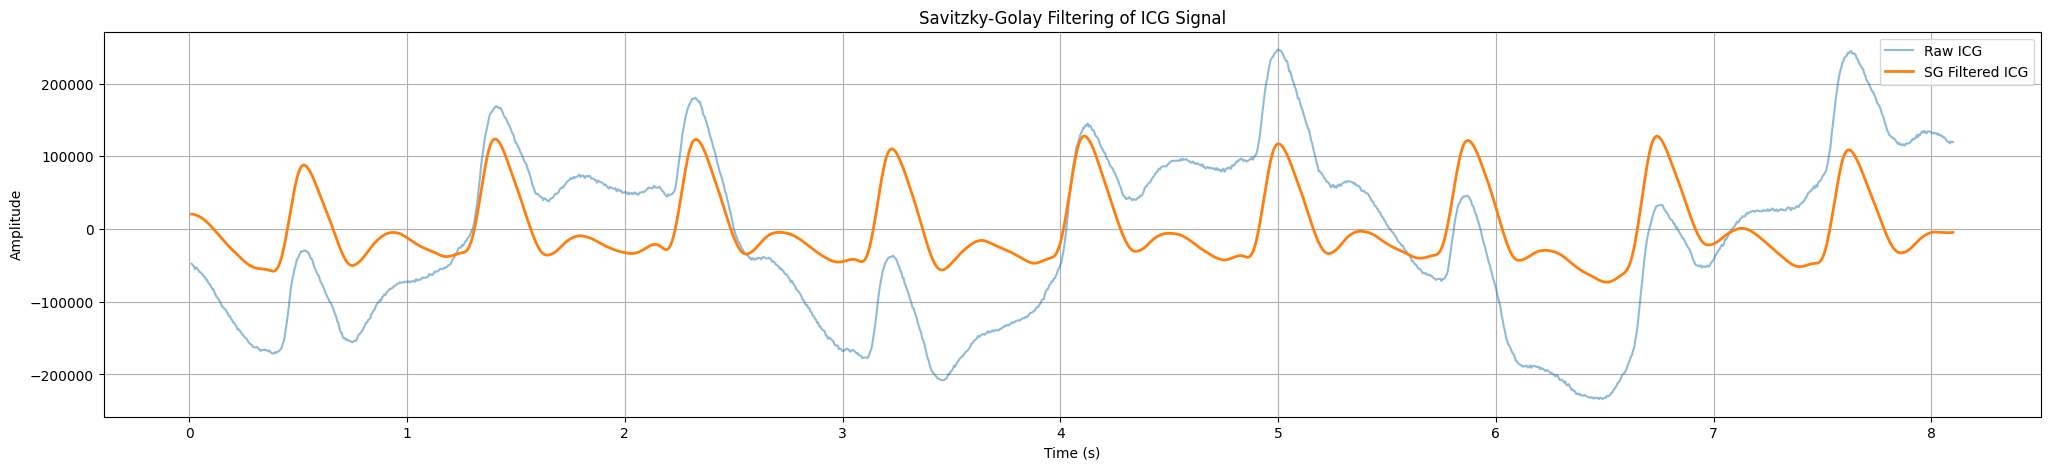

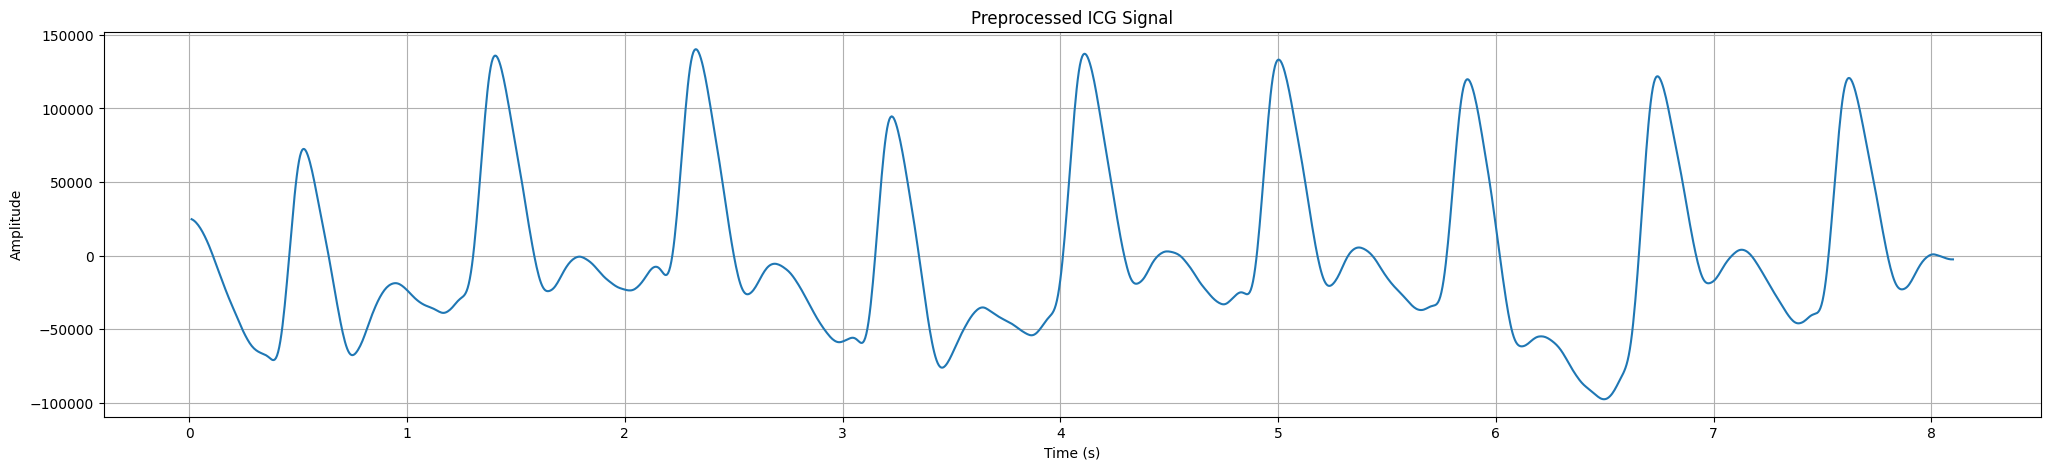

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, savgol_filter

def preprocess_icg(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=31, sg_poly=3):
    """
    Preprocess ICG signal: Bandpass filtering + Savitzky-Golay smoothing

    Parameters:
        icg_data (array): Raw ICG signal.
        icg_time (array): Time vector for the ICG signal.
        fs (float): Sampling frequency.
        lowcut (float): Low cutoff frequency for bandpass filter.
        highcut (float): High cutoff frequency for bandpass filter.
        order (int): Order of the Butterworth filter.
        sg_window (int): Window length for Savitzky-Golay filter (must be odd).
        sg_poly (int): Polynomial order for Savitzky-Golay filter.

    Returns:
        icg_sg (array): Smoothed ICG signal after preprocessing.
    """
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Plot: Raw vs Band-passed
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
    plt.plot(icg_time, icg_bandpassed, label=f'Band-passed ICG ({lowcut}–{highcut} Hz)', linewidth=2)
    plt.xlabel('Time (s)')
    plt.ylabel('Impedance (Ω)')
    plt.title('ICG Signal Band-pass Filtered')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Savitzky-Golay smoothing
    icg_sg = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)

    # Plot: Band-passed vs SG-smoothed
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.5)
    plt.plot(icg_time, icg_sg, label='SG Filtered ICG', linewidth=2)
    plt.legend()
    plt.title("Savitzky-Golay Filtering of ICG Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

    return icg_sg

icg_processed = preprocess_icg(icg_data, icg_time, fs)

plt.figure(figsize=(25, 5))
plt.plot(icg_time, icg_sg)
plt.title("Preprocessed ICG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

## Baseline removal

As we see this is not helping we use SG as a baseline corrector, we use SG to estimate the low-frequency trend (baseline), and then subtract it. Here, SG isn’t used to smooth the signal but to isolate the low-frequency component (like respiration or motion drift)

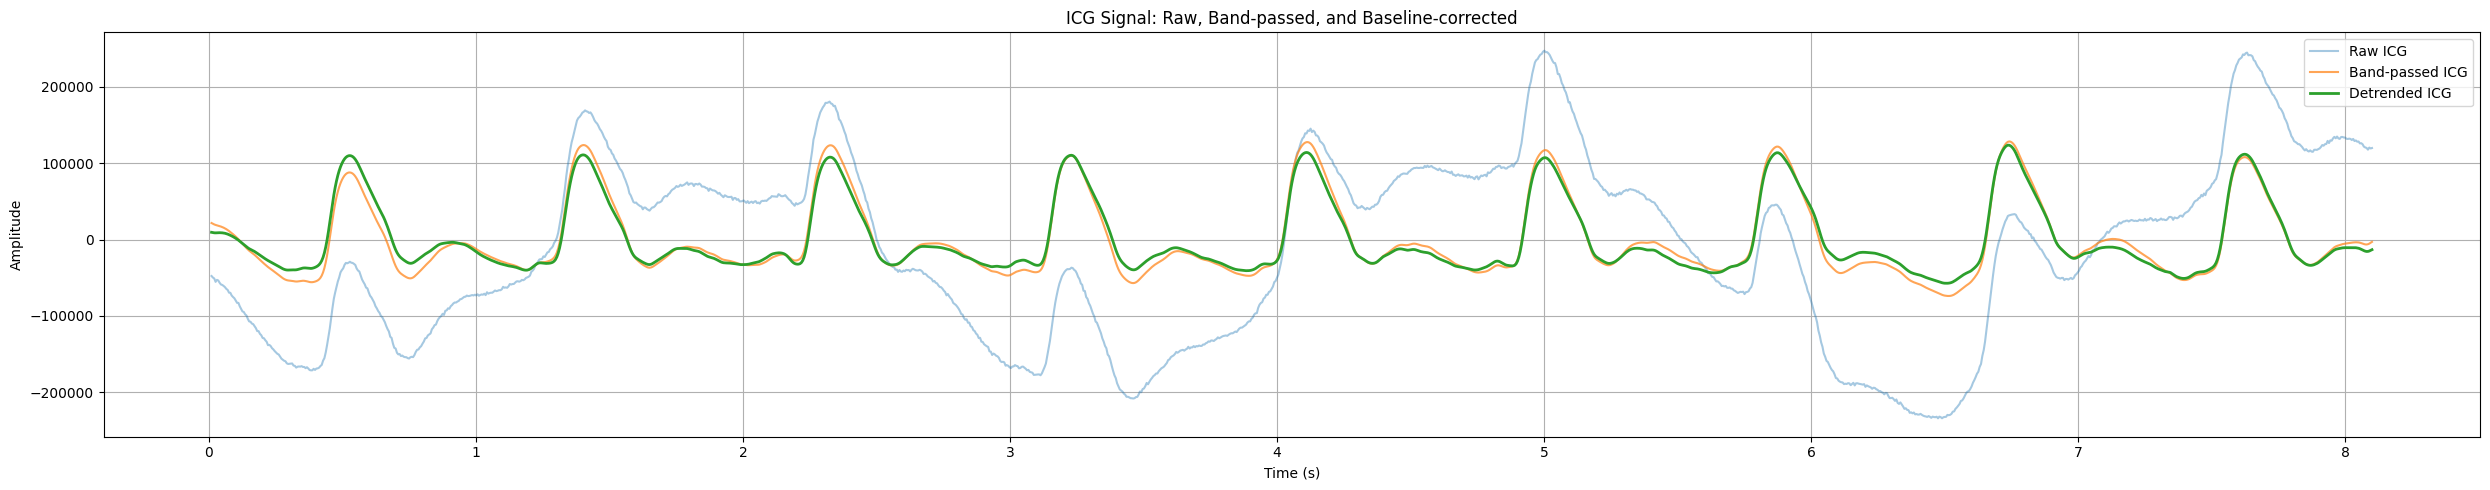

Text(0.5, 1.0, 'Preprocessed ICG Signal')

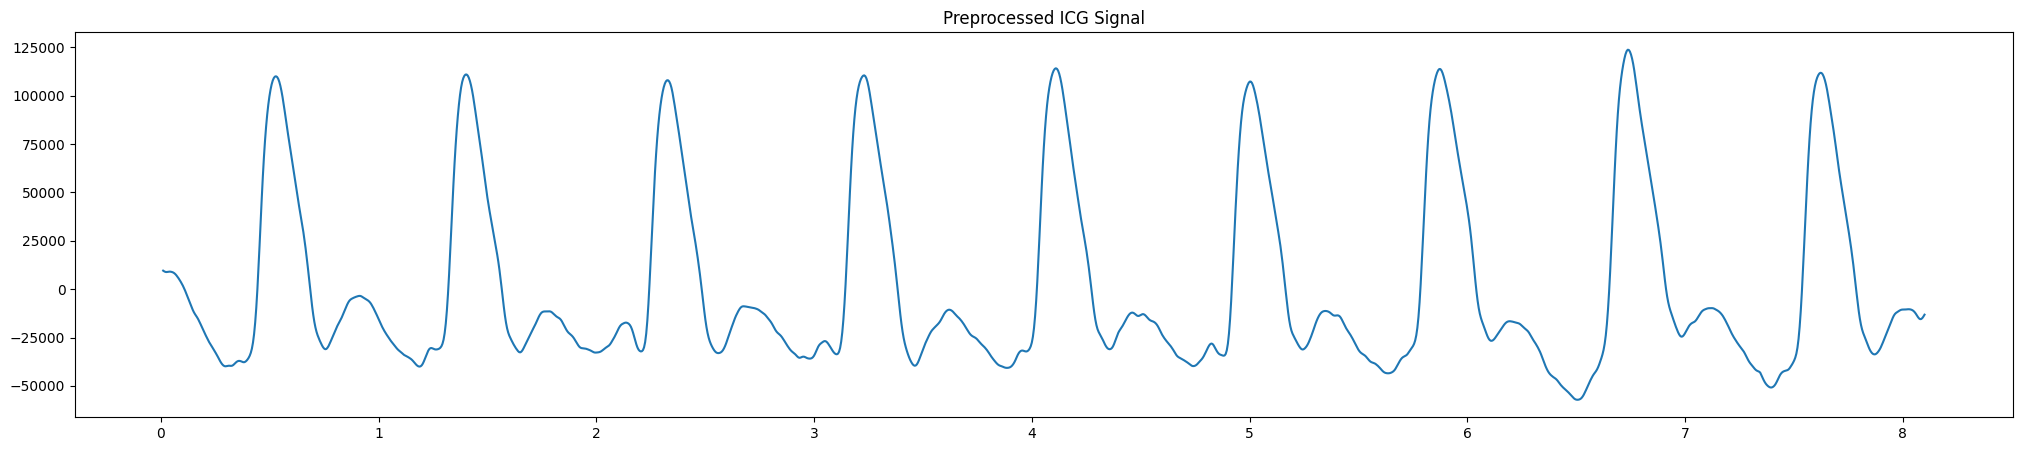

In [44]:
def preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2):
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Baseline estimation using SG and subtraction
    baseline = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)
    icg_detrended = icg_bandpassed - baseline

    # Plot
    plt.figure(figsize=(25, 5))
    plt.plot(icg_time, icg_data, label='Raw ICG', alpha=0.4)
    plt.plot(icg_time, icg_bandpassed, label='Band-passed ICG', alpha=0.7)
    plt.plot(icg_time, icg_detrended, label='Detrended ICG', linewidth=2)
    plt.legend()
    plt.title("ICG Signal: Raw, Band-passed, and Baseline-corrected")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return icg_detrended


icg_detrended = preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2)
plt.figure(figsize=(25, 5))
plt.plot(icg_time, icg_detrended)
plt.title("Preprocessed ICG Signal")

### Wavelet decomposition for electrode artifact
No effect

In [45]:
# import pywt

# # choose wavelet and decomposition level
# wavelet = 'db4'
# max_level = pywt.dwt_max_level(len(icg_data), pywt.Wavelet(wavelet).dec_len)
# level = min(5, max_level)  #safe max level

# # wavelet decomposition
# coeffs = pywt.wavedec(icg_data, wavelet, level=level)

# # estimate a threshold
# sigma = np.median(np.abs(coeffs[-1])) / 0.6745
# threshold = sigma * np.sqrt(2 * np.log(len(icg_data)))

# # soft thresholding to detail coefficients (ignore approximation at index 0)
# coeffs_thresh = [coeffs[0]] + [pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]]

# # reconstruct denoised signal
# icg_denoised = pywt.waverec(coeffs_thresh, wavelet)

# plt.figure(figsize=(12, 4))
# plt.plot(icg_time, icg_data, label='Original ICG', alpha=0.6)
# plt.plot(icg_time, icg_denoised, label='Denoised ICG', linewidth=2)
# plt.legend()
# plt.xlabel("Time (s)")
# plt.ylabel("ICG Signal")
# plt.title("ICG Signal Before and After Wavelet Denoising")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


# ECG + Preprocess

Sampling Frequency ECG 1: 198.78 Hz
Sampling Frequency ECG 2: 43814.13 Hz
Sampling Frequency ECG 3: 136.00 Hz
Sampling Frequency ECG 4: 496.09 Hz


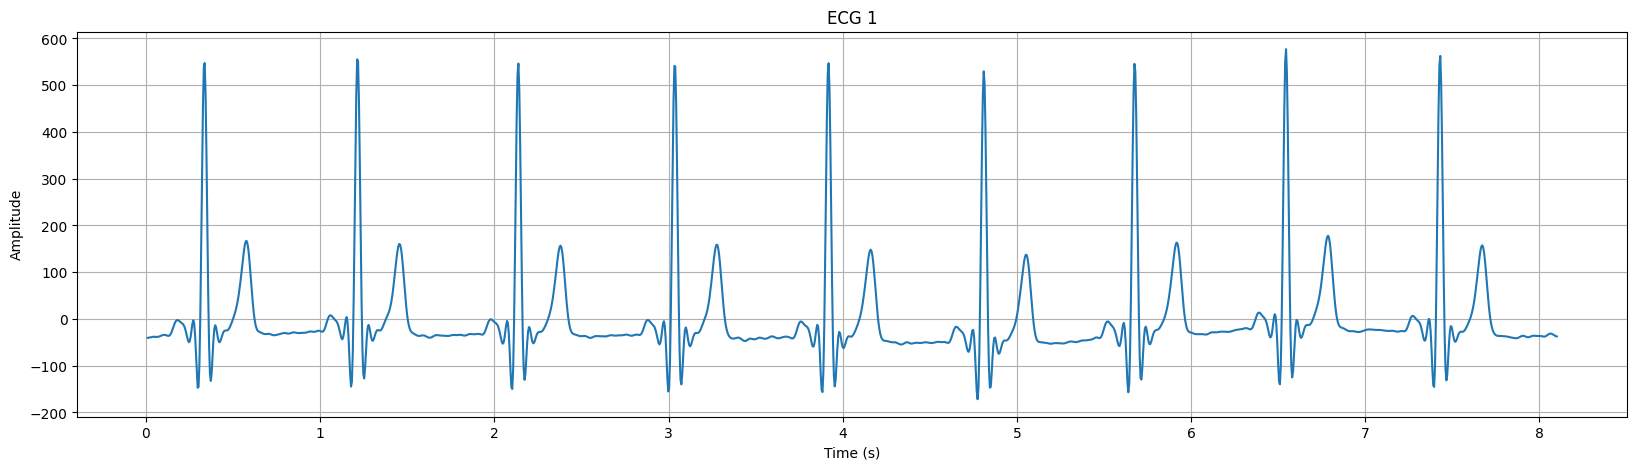

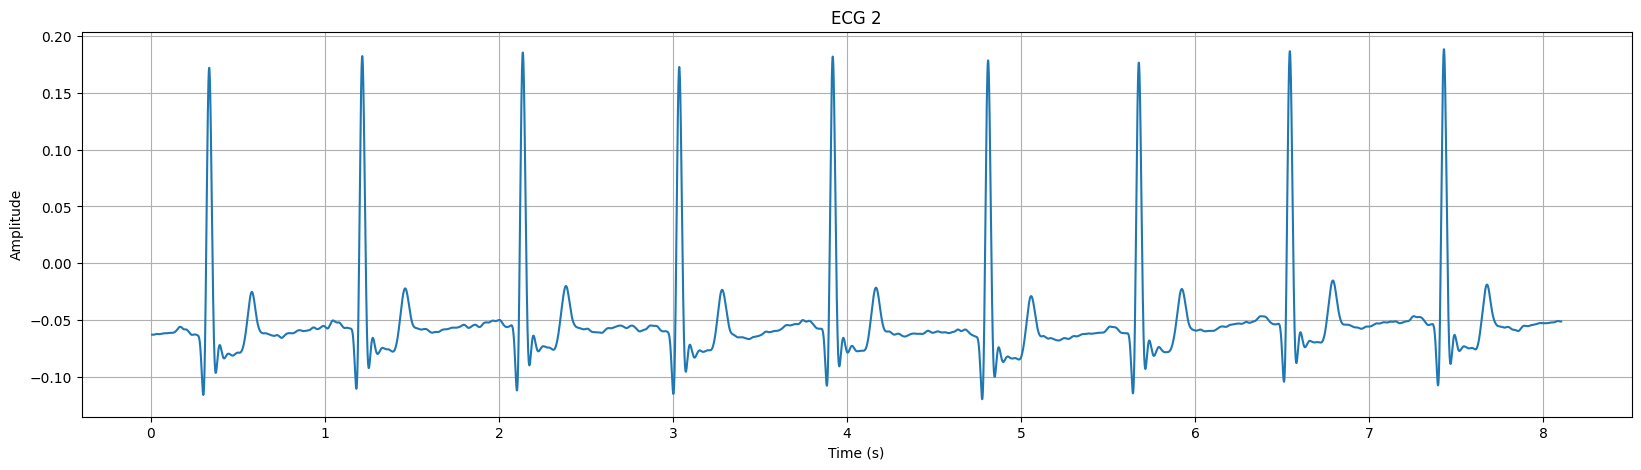

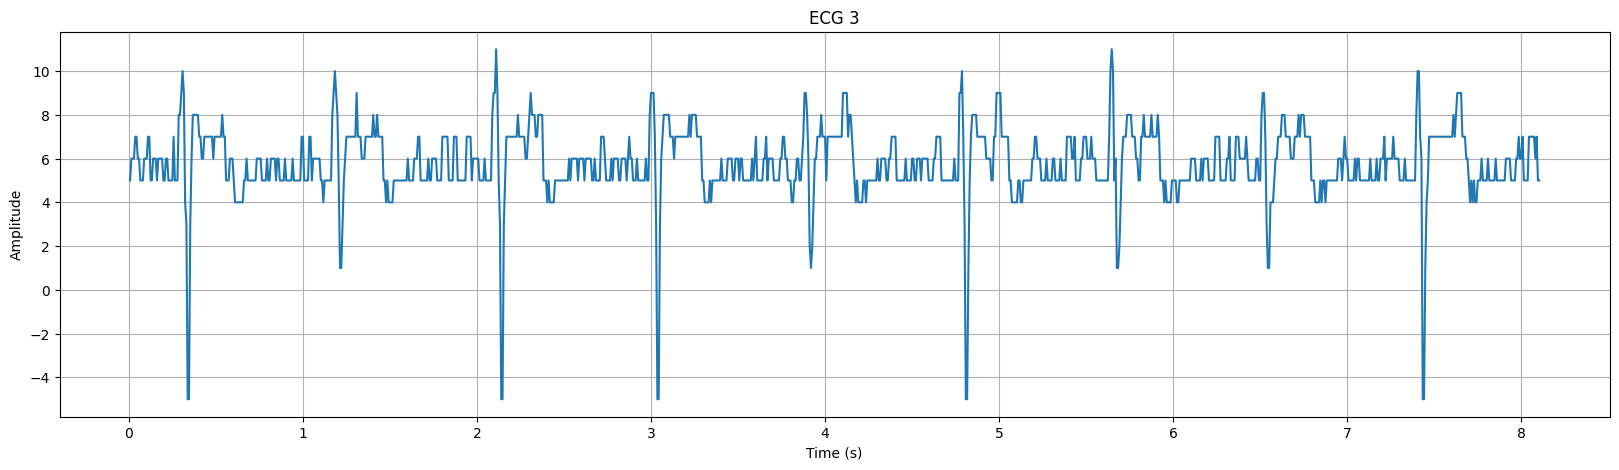

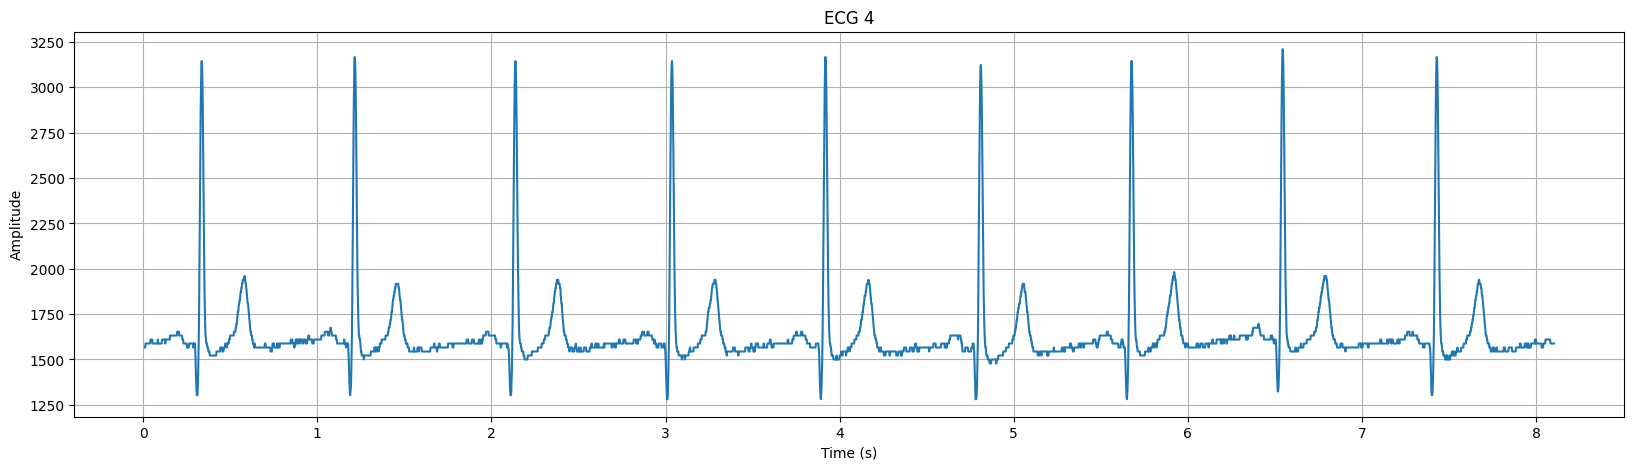

In [46]:
import matplotlib.pyplot as plt

ecg_1 = measures[0, 1]
ecg_2 = measures[0, 2]
ecg_3 = measures[0, 3]
ecg_4 = measures[0, 4]

ecg_1_time = ecg_1['time'][0, 0].flatten()
ecg_1_data = ecg_1['data'][0, 0].flatten()

ecg_2_time = ecg_2['time'][0, 0].flatten()
ecg_2_data = ecg_2['data'][0, 0].flatten()

ecg_3_time = ecg_3['time'][0, 0].flatten()
ecg_3_data = ecg_3['data'][0, 0].flatten()

ecg_4_time = ecg_4['time'][0, 0].flatten()
ecg_4_data = ecg_4['data'][0, 0].flatten()

# Plot ECG 1
plt.figure(figsize=(20, 5))
plt.plot(ecg_1_time, ecg_1_data)
plt.title('ECG 1')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 2
plt.figure(figsize=(20, 5))
plt.plot(ecg_2_time, ecg_2_data)
plt.title('ECG 2')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 3
plt.figure(figsize=(20, 5))
plt.plot(ecg_3_time, ecg_3_data)
plt.title('ECG 3')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot ECG 4
plt.figure(figsize=(20, 5))
plt.plot(ecg_4_time, ecg_4_data)
plt.title('ECG 4')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

def get_sampling_frequency(time_array):
    time_diffs = np.diff(time_array)
    avg_time_step = np.mean(time_diffs)
    fs = 1 / avg_time_step
    return fs

fs_1 = get_sampling_frequency(ecg_1_time)
fs_2 = get_sampling_frequency(ecg_2_time)
fs_3 = get_sampling_frequency(ecg_3_time)
fs_4 = get_sampling_frequency(ecg_4_time)

print(f"Sampling Frequency ECG 1: {fs_1:.2f} Hz")
print(f"Sampling Frequency ECG 2: {fs_2:.2f} Hz")
print(f"Sampling Frequency ECG 3: {fs_3:.2f} Hz")
print(f"Sampling Frequency ECG 4: {fs_4:.2f} Hz")

## ECG Preprocessing
We see ECG 1 most times has some baseline drifts, we use a band pass, with band of choice 0.05 Hz - 150 Hz (recommended by American Hearth Association), but we cannot bc: ValueError: Digital filter critical frequencies must be 0 < Wn < 1

The high cutoff frequency is too high relative to the Nyquist frequency (nyq = fs_3 / 2). The butter function requires normalized cutoff frequencies between 0 and 1, where 1 represents the Nyquist frequency.

We see that the notch doesn't affect the data.


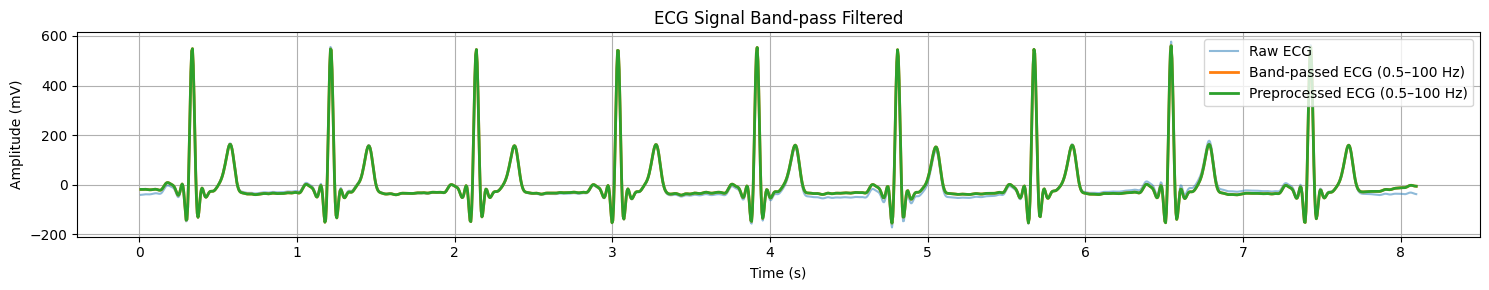

In [47]:
from scipy.signal import iirnotch

def notch_filter(data, fs, freq=50, quality_factor=30):
    b, a = iirnotch(freq, quality_factor, fs)
    return filtfilt(b, a, data)

ecg_1_bandpassed = bandpass(ecg_1_data, fs_1, 0.5,45)
ecg_1_preprocessed = notch_filter(ecg_1_bandpassed, fs_1, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_1_time, ecg_1_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_1_time, ecg_1_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_1_time, ecg_1_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

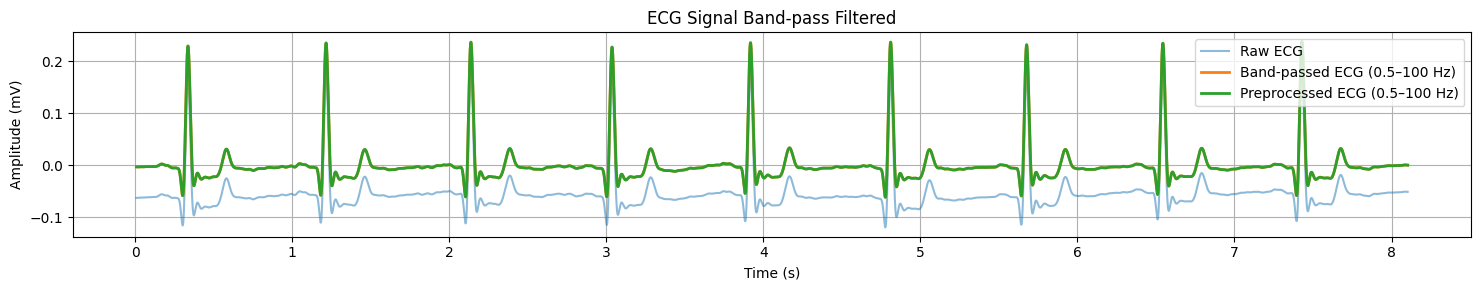

In [48]:
ecg_2_bandpassed = bandpass(ecg_2_data, fs_2, 0.5,100)
ecg_2_preprocessed = notch_filter(ecg_2_bandpassed, fs_2, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_2_time, ecg_2_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_2_time, ecg_2_bandpassed, label='Band-passed ECG (0.5–100 Hz)', linewidth=2)
plt.plot(ecg_2_time, ecg_2_preprocessed, label='Preprocessed ECG (0.5–100 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

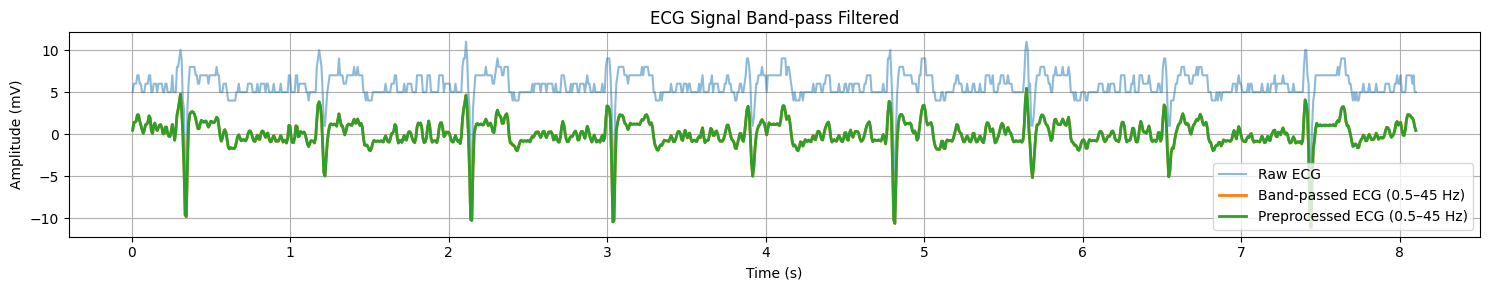

In [49]:
ecg_3_bandpassed = bandpass(ecg_3_data, fs_3, 0.5, 45)
ecg_3_preprocessed = notch_filter(ecg_3_bandpassed, fs_3, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_3_time, ecg_3_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_3_time, ecg_3_bandpassed, label='Band-passed ECG (0.5–45 Hz)', linewidth=2)
plt.plot(ecg_3_time, ecg_3_preprocessed, label='Preprocessed ECG (0.5–45 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


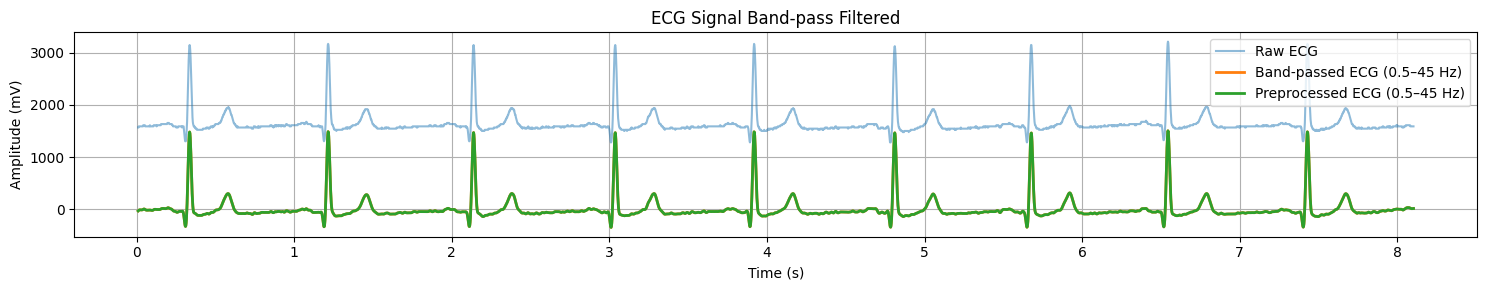

In [50]:
ecg_4_bandpassed = bandpass(ecg_4_data, fs_4, 0.5, 45)
ecg_4_preprocessed = notch_filter(ecg_4_bandpassed, fs_4, freq=50, quality_factor=30)

plt.figure(figsize=(15, 3))
plt.plot(ecg_4_time, ecg_4_data, label='Raw ECG', alpha=0.5)
plt.plot(ecg_4_time, ecg_4_bandpassed, label='Band-passed ECG (0.5–45 Hz)', linewidth=2)
plt.plot(ecg_4_time, ecg_4_preprocessed, label='Preprocessed ECG (0.5–45 Hz)', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal Band-pass Filtered')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Echo

[[array([[7.35294118e-03],
         [1.47058824e-02],
         [2.20588235e-02],
         ...,
         [8.08823529e+00],
         [8.09558824e+00],
         [8.10294118e+00]])]]
(274, 1102)


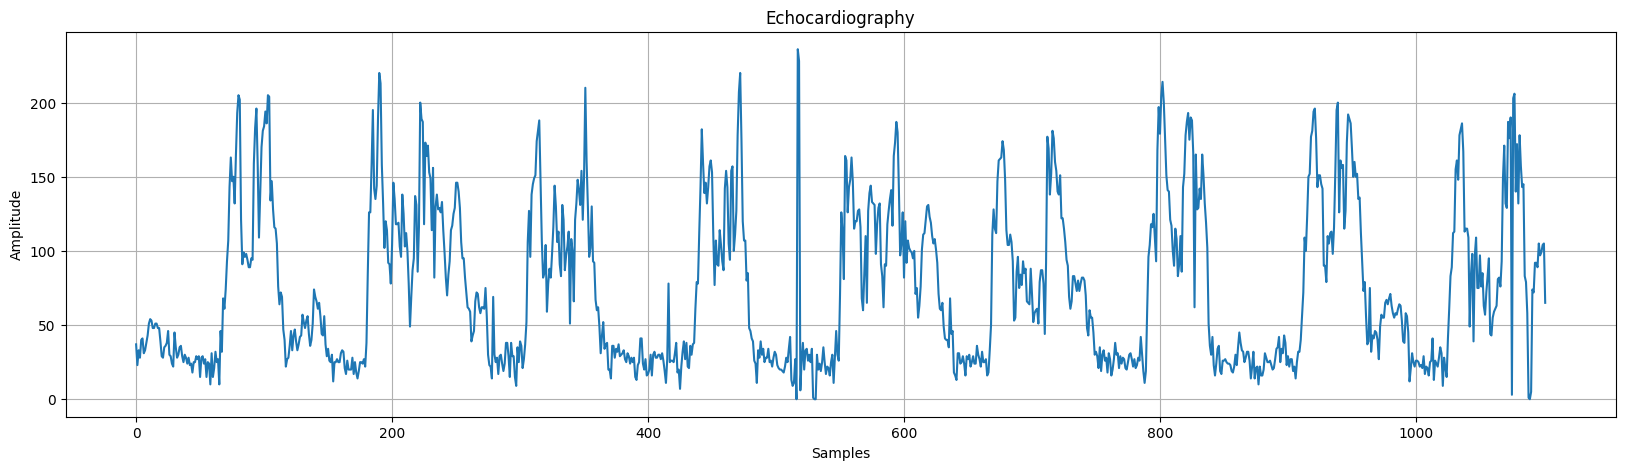

[7.35294118e-03 1.47058824e-02 2.20588235e-02 ... 8.08823529e+00
 8.09558824e+00 8.10294118e+00]
Sampling frequency: 136.00 Hz


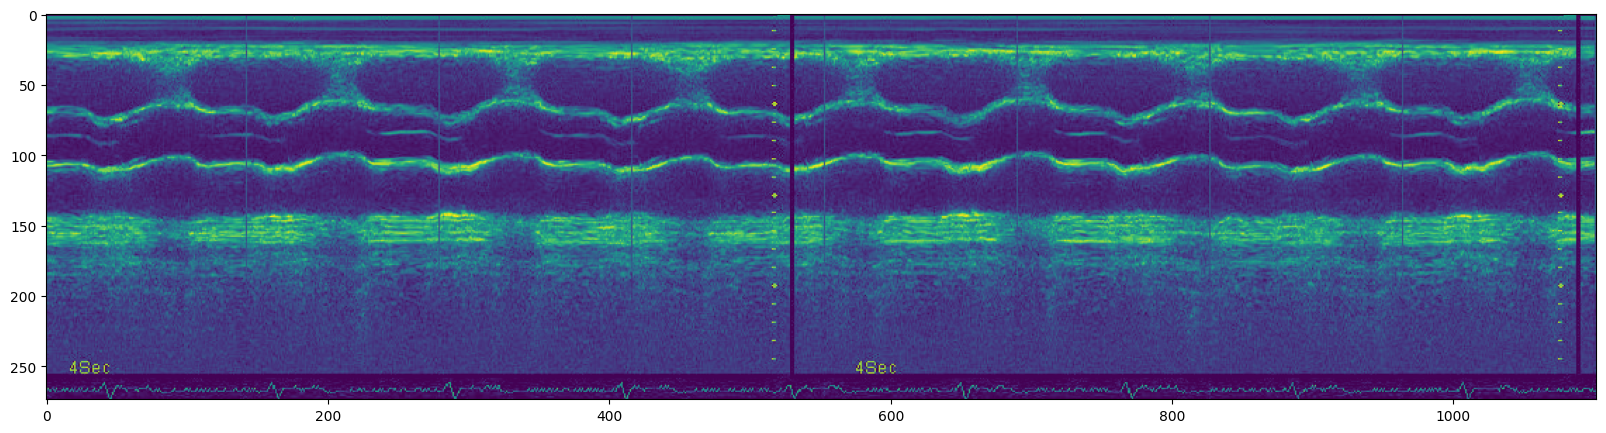

In [51]:
echo = measures[1,3]
echo_time = echo['time']
echo_data = echo['data']
echo_value = echo_data[0, 0]

print(echo_time)

echo_value_1 = echo_value[:, :, 0]  #all time frames, channel 0, covering all depth points
print(echo_value_1.shape)
#it means we extract all lines

echo_one_line = echo_value[65, :, 0] #we see in the echo picture that not all depths are information so we choose one that helps finding AVO and AVC
plt.figure(figsize=(20, 5))
plt.plot(echo_one_line)
plt.title('Echocardiography')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# we look at the echo image
plt.figure(figsize=(20, 8))
plt.imshow(echo_value_1)

# Unwrap the echo_time to get the 2D array inside the list
echo_time_array = echo_time[0]  # unwrap the list
echo_time_flat = echo_time_array[0]
echo_really_flat = echo_time_flat.flatten()  # flatten to 1D
print(echo_really_flat)

# Calculate the time step
dt = echo_really_flat[1] - echo_really_flat[0]
fs_echo = 1 / dt

print(f"Sampling frequency: {fs_echo:.2f} Hz")


274
[26 25 21 ... 32 21 72]


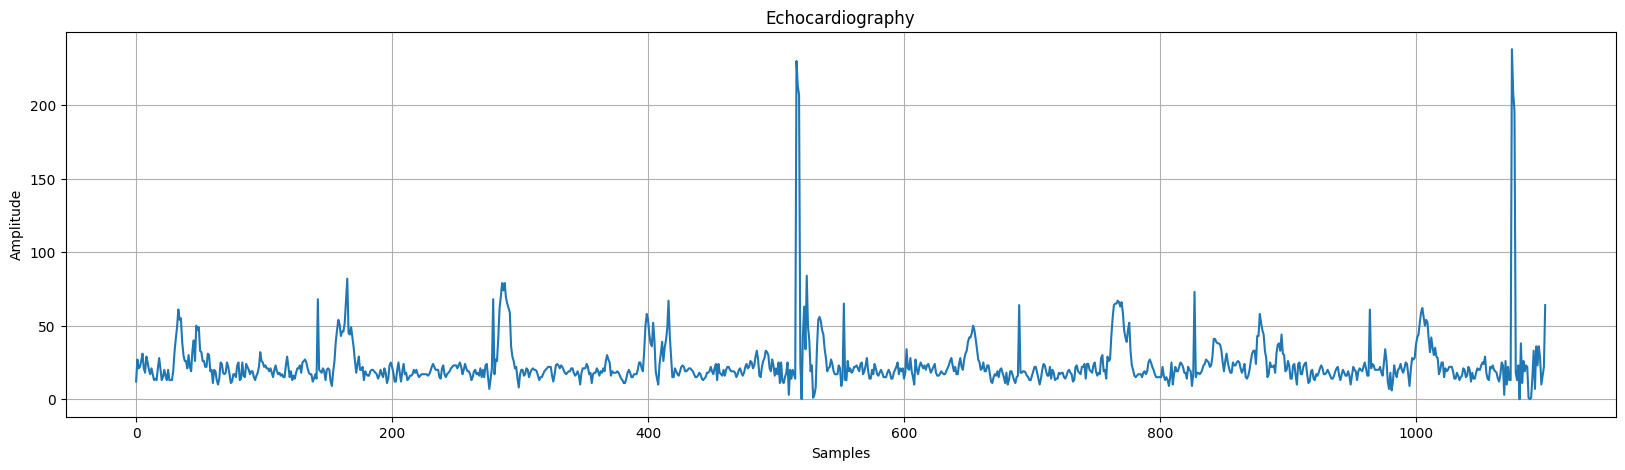

In [52]:
depth_count = echo_value.shape[0]

all_echo_lines = []

for i in range(depth_count):
    echo_value_i = echo_data[0, 0][i, :, 0]  # or echo_value[i, :, 0] if echo_value is still valid
    all_echo_lines.append(echo_value_i)

print(len(all_echo_lines)) #274 lines
print(all_echo_lines[131])

plt.figure(figsize=(20, 5))
plt.plot(all_echo_lines[90])
plt.title('Echocardiography')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# we extract all lines to use it later

# R peaks

### ECG + ICG + R peaks

[0.33735509 1.21268387 2.1383189  3.03377018 3.91916021 4.80958087
 5.6748484  6.54514655 7.43053658]


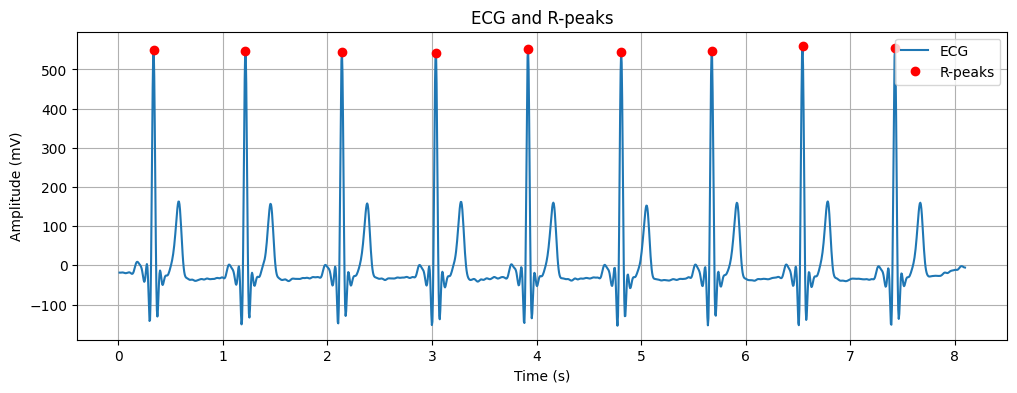

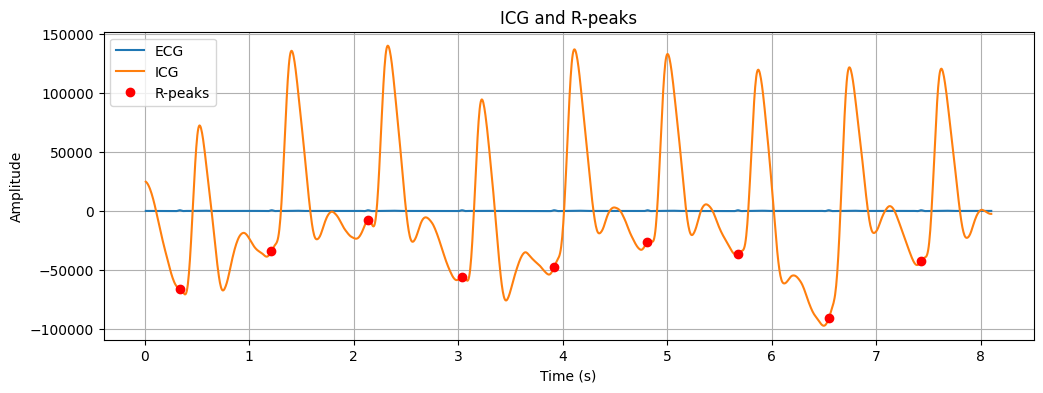

In [53]:
rpeaks = measures[2,1]
rpeaks_time = rpeaks['time'][0,0].flatten()
rpeaks_values = rpeaks['data'][0,0].flatten()
#print(rpeaks_values)

# numpy array?
rpeaks_times = np.array(rpeaks_values)
print(rpeaks_times)

# find the closest points to the time second
rpeaks_index = np.array([np.argmin(np.abs(ecg_1_time - t)) for t in rpeaks_times])

plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_preprocessed, label='ECG')
plt.plot(ecg_1_time[rpeaks_index], ecg_1_preprocessed[rpeaks_index], 'ro', label='R-peaks') #put the r peaks in red points
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(ecg_1_time, ecg_1_preprocessed,label='ECG')
plt.plot(icg_time, icg_sg, label='ICG')
plt.plot(icg_time[rpeaks_index], icg_sg[rpeaks_index], 'ro', label='R-peaks') #put the r peaks in red points, also it puts it in the amplitude where the signal is
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


We see that ECG is much more flat because it's not scaled well, we normalise between 0 and 1 to see them properly

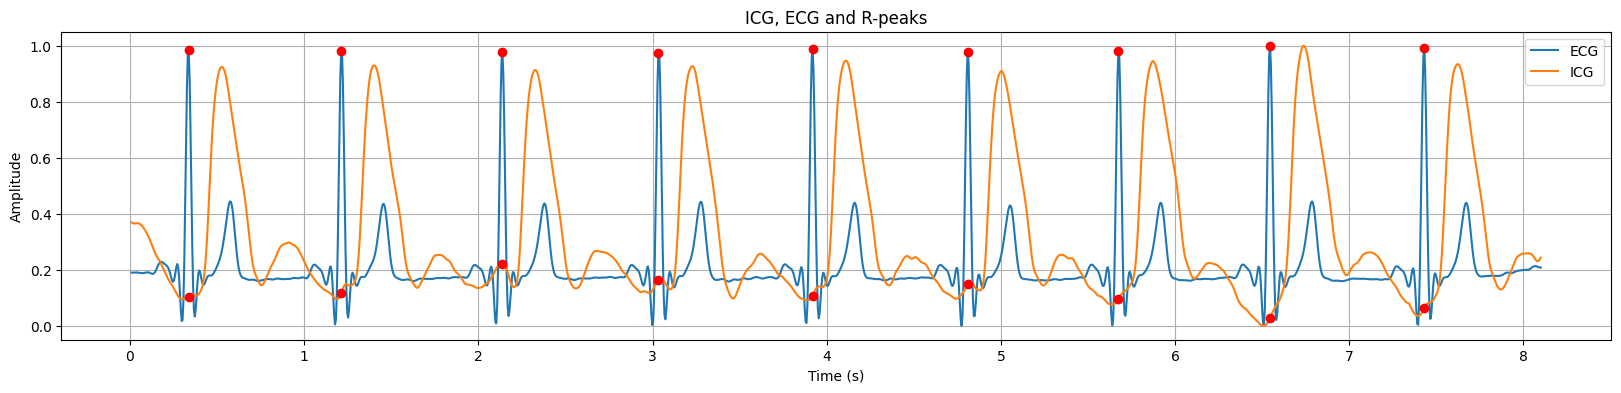

In [54]:
def normalize(signal):
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

ecg_norm = normalize(ecg_1_preprocessed)
icg_norm = normalize(icg_detrended)

plt.figure(figsize=(20, 4))
plt.plot(ecg_1_time, ecg_norm, label='ECG')
plt.plot(icg_time, icg_norm, label='ICG')
plt.plot(ecg_1_time[rpeaks_index], ecg_norm[rpeaks_index], 'ro')
plt.plot(icg_time[rpeaks_index], icg_norm[rpeaks_index],'ro')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG, ECG and R-peaks')
plt.legend()
plt.grid(True)
plt.show()


# Signal correlation
## Pearson's test

Weak but statistically significant positive correlation (r ≈ 0.16, p < 0.001) between the preprocessed ICG and ECG signals, suggesting a modest linear relationship after preprocessing.

Negligible and non-significant correlation (r ≈ 0.04, p ≈ 0.14) in raw data.

The preprocessing enhances the relationship of the signals. However, the overall low correlation values suggest that ICG and ECG signals are not strongly correlated.

In [55]:
from scipy.stats import pearsonr

# ICG preprocessed and ECG preprocessed
correlation_coefficient, p_value = pearsonr(icg_detrended, ecg_1_preprocessed)

print(f"Pearson's Correlation Coefficient Preprocessed: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG raw and ECG raw
correlation_coefficient, p_value = pearsonr(icg_data, ecg_1_data)

print(f"Pearson's Correlation Coefficient Raw: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG raw and ECG preprocessed
correlation_coefficient, p_value = pearsonr(icg_data, ecg_1_preprocessed)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG preprocessed and ECG raw
correlation_coefficient, p_value = pearsonr(icg_detrended, ecg_1_data)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG bandpassed and ECG raw
correlation_coefficient, p_value = pearsonr(icg_bandpassed, ecg_1_data)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG bandpassed and ECG preprocessed
correlation_coefficient, p_value = pearsonr(icg_bandpassed, ecg_1_preprocessed)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG bandpassed and ECG bandpassed
correlation_coefficient, p_value = pearsonr(icg_bandpassed, ecg_1_bandpassed)

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

# ICG bandpassed and echo line
#correlation_coefficient, p_value = pearsonr(icg_bandpassed, all_echo_lines[90])

print(f"Pearson's Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

Pearson's Correlation Coefficient Preprocessed: 0.17511112273048393
P-value: 1.5120607928782275e-12
Pearson's Correlation Coefficient Raw: 0.028987522249135565
P-value: 0.24519567578932047
Pearson's Correlation Coefficient: 0.0677507319940039
P-value: 0.006554840700457127
Pearson's Correlation Coefficient: 0.1790185613058191
P-value: 4.697192111536629e-13
Pearson's Correlation Coefficient: 0.14463914007231454
P-value: 5.610348594415087e-09
Pearson's Correlation Coefficient: 0.15440966459519803
P-value: 4.775927809659778e-10
Pearson's Correlation Coefficient: 0.15439770272846615
P-value: 4.790825212533372e-10
Pearson's Correlation Coefficient: 0.15439770272846615
P-value: 4.790825212533372e-10


In [56]:
import pandas as pd
from scipy.stats import pearsonr

results = []

# 1. ICG preprocessed vs ECG preprocessed
r, p = pearsonr(icg_detrended, ecg_1_preprocessed)
results.append(["ICG Preprocessed", "ECG Preprocessed", r, p])

# 2. ICG Raw vs ECG Raw
r, p = pearsonr(icg_data, ecg_1_data)
results.append(["ICG Raw", "ECG Raw", r, p])

# 3. ICG Raw vs ECG Preprocessed
r, p = pearsonr(icg_data, ecg_1_preprocessed)
results.append(["ICG Raw", "ECG Preprocessed", r, p])

# 4. ICG Preprocessed vs ECG Raw
r, p = pearsonr(icg_detrended, ecg_1_data)
results.append(["ICG Preprocessed", "ECG Raw", r, p])

# 5. ICG Bandpassed vs ECG Raw
r, p = pearsonr(icg_bandpassed, ecg_1_data)
results.append(["ICG Bandpassed", "ECG Raw", r, p])

# 6. ICG Bandpassed vs ECG Preprocessed
r, p = pearsonr(icg_bandpassed, ecg_1_preprocessed)
results.append(["ICG Bandpassed", "ECG Preprocessed", r, p])

# 7. ICG Bandpassed vs ECG Bandpassed
r, p = pearsonr(icg_bandpassed, ecg_1_bandpassed)
results.append(["ICG Bandpassed", "ECG Bandpassed", r, p])

# Create DataFrame
df = pd.DataFrame(results, columns=["ICG Signal", "ECG Signal", "Pearson's r", "P-value"])
df_rounded = df.copy()
df_rounded[["Pearson's r", "P-value"]] = df_rounded[["Pearson's r", "P-value"]].round(6)

print(df_rounded)



         ICG Signal        ECG Signal  Pearson's r   P-value
0  ICG Preprocessed  ECG Preprocessed     0.175111  0.000000
1           ICG Raw           ECG Raw     0.028988  0.245196
2           ICG Raw  ECG Preprocessed     0.067751  0.006555
3  ICG Preprocessed           ECG Raw     0.179019  0.000000
4    ICG Bandpassed           ECG Raw     0.144639  0.000000
5    ICG Bandpassed  ECG Preprocessed     0.154410  0.000000
6    ICG Bandpassed    ECG Bandpassed     0.154398  0.000000


# ICG delineation algorithm

### C point detection

In [57]:
rr_int = np.diff(rpeaks_times) #rr intervals
print(rr_int)

[0.87532878 0.92563503 0.89545128 0.88539003 0.89042066 0.86526753
 0.87029815 0.88539003]


In [58]:
def find_c_peaks(icg, rr_int):
    """
    Finds the maximum value (C peak) within each RR interval in the ICG signal.

    Input:
        icg: The preprocessed ICG signal.
        rr_int:  The RR intervals (beat-to-beat intervals).

    Output:
        A list of C peak values.
    """
    c_peaks = []
    start_index = 0
    for rr in rr_int:
        end_index = start_index + int(round(rr * fs)) # Convert seconds to samples
        if end_index >= len(icg_sg):
            end_index = len(icg_sg) -1 #handle edge cases where the end_index exceeds the signal length
        c_peaks.append(np.max(icg_sg[start_index:end_index]))
        start_index = end_index
    return c_peaks

c_peaks_values = find_c_peaks(icg_detrended, rr_int)
print("C-peak values:", c_peaks_values)

C-peak values: [np.float64(72511.5543588138), np.float64(135896.23017985077), np.float64(140216.2881197604), np.float64(94620.29528777456), np.float64(137138.84900722888), np.float64(133145.18092484993), np.float64(119864.86082869963), np.float64(121868.173588501)]


#### Plotting C peaks

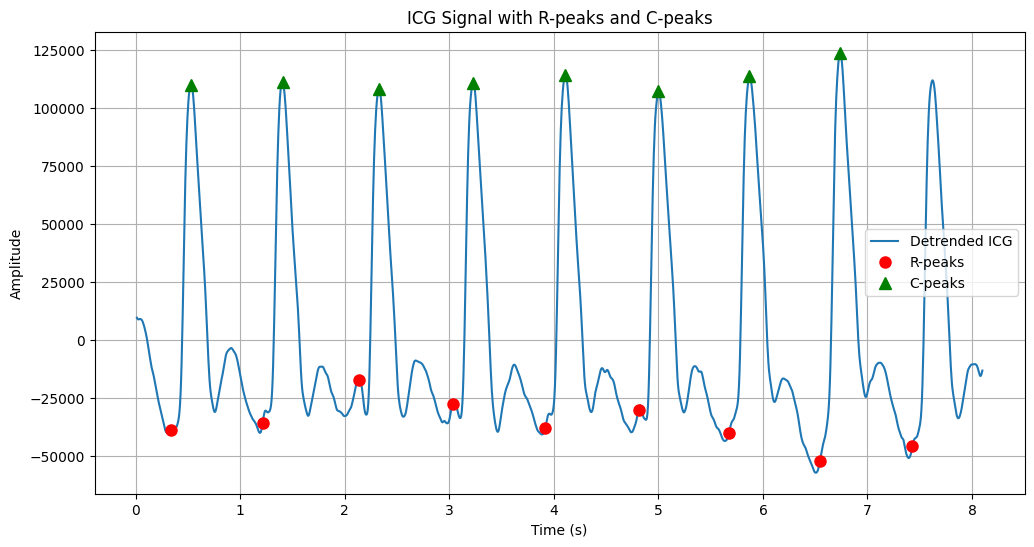

[np.float64(0.5285188482793366), np.float64(1.4038476278505279), np.float64(2.3244520339512675), np.float64(3.2299645645421613), np.float64(4.110323969283307), np.float64(5.000744624364348), np.float64(5.871042778765592), np.float64(6.736310307996888)]
[np.float64(109971.51814944344), np.float64(110900.08676889761), np.float64(107918.29387977379), np.float64(110446.13323627111), np.float64(114089.03419576008), np.float64(107240.77652793899), np.float64(113720.51020484602), np.float64(123663.35962885087)]


In [59]:
# Find the indices of the R-peaks in the ICG signal's time vector
rpeaks_index = np.array([np.argmin(np.abs(icg_time - t)) for t in rpeaks_times])

# Plot the C peaks over the ICG
plt.figure(figsize=(12, 6))
plt.plot(icg_time, icg_detrended, label='Detrended ICG')
plt.plot(icg_time[rpeaks_index], icg_detrended[rpeaks_index], 'ro', markersize=8, label='R-peaks')

# Calculate RR intervals (if not already defined)
rr_int = np.diff(rpeaks_times)

C_peak_times = []
C_peaks_values = []  # Added to store amplitude values
start_index = 0
for i, rr in enumerate(rr_int):
    end_index = start_index + int(round(rr * fs))
    if end_index >= len(icg_detrended):
        end_index = len(icg_detrended) - 1
    current_max_idx = start_index + np.argmax(icg_detrended[start_index:end_index])
    C_peak_times.append(icg_time[current_max_idx])
    C_peaks_values.append(icg_detrended[current_max_idx])  # Store amplitude
    start_index = rpeaks_index[i+1]  # Move to next R-peak index

# Plot C-peaks (fixed the string quote and variable name)
plt.plot(C_peak_times, C_peaks_values, 'g^', markersize=8, label='C-peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG Signal with R-peaks and C-peaks')
plt.legend()
plt.grid(True)
plt.show()
print(C_peak_times)
print(C_peaks_values)

### B points

Options:
- the B point is detected as the sign change within 20% and 65% of the R–C interval window of the ICG first derivative [ReBeat]

- 15% response from the baseline [14 de Systematic Variability]

- equation that relates the R peak of the electrocardiography (ECG) signal and the C peak of the dZ/dt signal; RB = 1.233RE -0.0032RE2 - 31.59 [11 de Systematic Variability]

- From what I see is that the B point is the lowest point between R and C

##### This is what i supposed, however, not correct because it detects the same point as for the R peaks

[np.float64(0.5285188482793366), np.float64(1.4038476278505279), np.float64(2.3244520339512675), np.float64(3.2299645645421613), np.float64(4.110323969283307), np.float64(5.000744624364348), np.float64(5.871042778765592), np.float64(6.736310307996888)]
[np.float64(109971.51814944344), np.float64(110900.08676889761), np.float64(107918.29387977379), np.float64(110446.13323627111), np.float64(114089.03419576008), np.float64(107240.77652793899), np.float64(113720.51020484602), np.float64(123663.35962885087)]


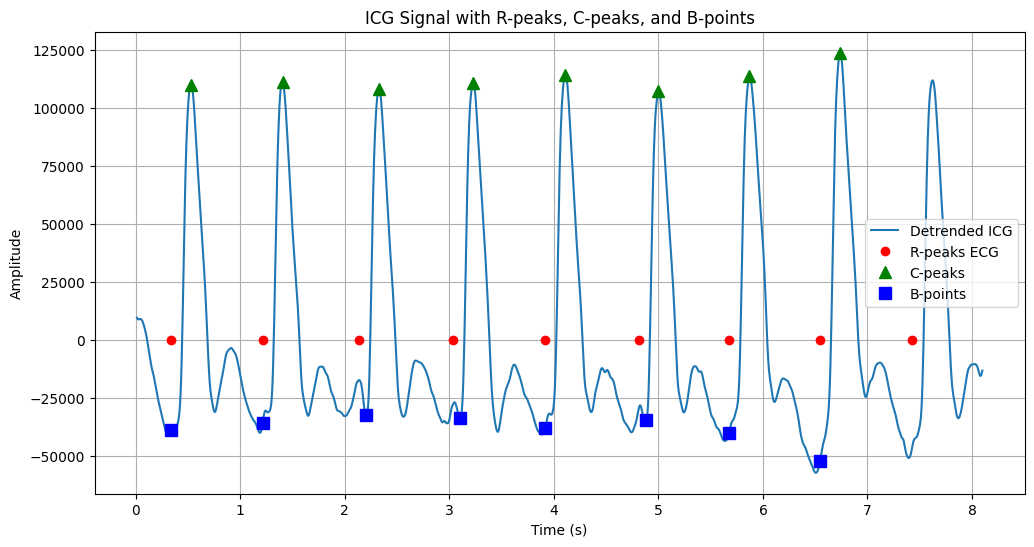

In [60]:
def find_b_points(icg_signal, rpeaks_index, c_peak_times):
    """
    Finds the B points (minimum points) between R and C peaks in the ICG signal.

    Args:
        icg_signal: The ICG signal data (NumPy array).
        rpeaks_index: Indices of the R-peaks in the ICG signal.
        c_peak_times: Time points of the C-peaks.

    Returns:
        A list of tuples, where each tuple contains the time and amplitude of a B point.
    """
    b_points = []
    for i in range(len(rpeaks_index) -1):  # Iterate through each RR interval
        r_index = rpeaks_index[i]
        next_r_index = rpeaks_index[i+1]

        # Find the index of the C peak corresponding to the current R peak
        c_peak_time = c_peak_times[i]
        c_peak_index = np.argmin(np.abs(icg_time - c_peak_time))

        # Find the minimum value between R and C peaks
        segment = icg_signal[r_index:c_peak_index]
        if len(segment) > 0 :
          min_index_in_segment = np.argmin(segment)
          b_point_index = r_index + min_index_in_segment
          b_points.append((icg_time[b_point_index], icg_signal[b_point_index]))
    return b_points

b_points = find_b_points(icg_detrended, rpeaks_index, C_peak_times)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(icg_time, icg_detrended, label='Detrended ICG')
plt.plot(icg_time[rpeaks_index], icg_norm[rpeaks_index],'ro',label='R-peaks ECG')
plt.plot(C_peak_times, C_peaks_values, 'g^', markersize=8, label='C-peaks')
print(C_peak_times)
print(C_peaks_values)


for b_time, b_amplitude in b_points:
    plt.plot(b_time, b_amplitude, 'bs', markersize=8, label='B-points' if not b_points.index((b_time, b_amplitude)) else "") # Add label only to the first b point


plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG Signal with R-peaks, C-peaks, and B-points')
plt.legend()
plt.grid(True)
plt.show()


measures[4,1] -> ['PPEjec']

measures[4,2] -> ['PEP']

measures[4,3] -> ['PEP']

measures[4,4] -> ['PEP']


[100 100 105 105  95 105 105 105 100]


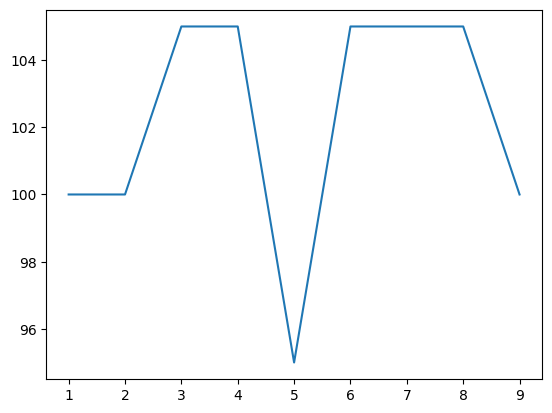

In [61]:
pep = measures[4, 1]
pep_data = pep['data'][0,0].flatten()  # Access data and flatten
pep_time = pep['time'][0,0].flatten()  # Access time and flatten
print(pep_data)
plt.plot(pep_time,pep_data)



In [62]:
# rpeaks = measures[2,1]
# rpeaks_time = rpeaks['time'][0,0].flatten()
# rpeaks_values = rpeaks['data'][0,0].flatten()
# print(rpeaks_values)

# # numpy array?
# rpeaks_times = np.array(rpeaks_values)
# print(rpeaks_times)


# b_points = find_b_points(icg_detrended, rpeaks_index, C_peak_times)
# # Convert b_points to a numpy array
# b_points_np = np.array(b_points)

# # Access the second column (amplitude values)
# b_value = b_points_np[:, 0]

# print(b_value)


### We use the ReBeat algorithm to find the B point

In [63]:
def find_b_point(sig, Cpos, CAmpl, Afrac, Fs, Bslope1, Bslope2):
    """
    Find the B point in the ICG signal.

    Inputs:
    - sig: ICG signal (numpy array or list), e.g., icg_detrended
    - Cpos: Time of C peak (in seconds)
    - CAmpl: Amplitude at C peak
    - Afrac: Fraction of C amplitude to define BlimR threshold
    - Fs: Sampling frequency (Hz)
    - Bslope1: Slope threshold for steep descent
    - Bslope2: Slope threshold for strong positive slope

    Returns:
    - BlimL_time: Left limit of B window (in seconds)
    - BlimR_time: Right limit of B window (in seconds)
    """
    # Convert seconds to sample index
    C_idx = int(Cpos * Fs)
    offset_samples = int(0.08 * Fs)
    BlimL_idx = C_idx - offset_samples

    threshold = Afrac * CAmpl
    BlimR_idx = None
    for i in range(C_idx, BlimL_idx, -1):
        if sig[i] <= threshold:
            BlimR_idx = i
            break

    if BlimR_idx is None:
        BlimR_idx = BlimL_idx

    # Convert back to seconds for output
    BlimL_time = BlimL_idx / Fs
    BlimR_time = BlimR_idx / Fs

    return BlimL_time, BlimR_time

# Afrac = 0.5
# Bslope1 = 0.11
# Bslope2 = 0.08

i = 0  # example: first C peak

# Extract the single C peak time and value
Cpos = C_peak_times[i]
CAmpl = C_peaks_values[i]

# Make sure your signal is a NumPy array
sig = np.array(icg_detrended)

# Now call the function
BlimL, BlimR = find_b_point(sig, Cpos, CAmpl, 0.5, fs, 0.11, 0.08)

print("BlimL (s):", BlimL)
print("BlimR (s):", BlimR)


BlimL (s): 0.4527562652954456
BlimR (s): 0.4527562652954456


In [64]:
import numpy as np
from scipy.signal import argrelextrema

def find_B_points(sig, C_pos_list, C_Ampl_list, A_frac=0.5, B_slope1=0.11, B_slope2=0.08, Fs=1000):
    """
    Detect B points for a list of C points.

    Parameters:
        sig         : 1D numpy array of the ICG signal
        C_pos_list  : list or array of indices for C points (can be float, will be cast to int)
        C_Ampl_list : list or array of amplitudes at C points
        A_frac      : fraction of C amplitude to determine BlimR
        B_slope1    : slope threshold for the first pass
        B_slope2    : slope threshold for the second pass
        Fs          : sampling frequency in Hz

    Returns:
        List of B point indices (same length as C_pos_list)
    """
    sig_deriv = np.gradient(sig)
    B_points = []

    for C_pos, C_Ampl in zip(C_pos_list, C_Ampl_list):
        C_pos = int(round(C_pos))  # convert to integer index
        BlimL = max(0, C_pos - int(0.08 * Fs))

        A_thresh = A_frac * C_Ampl
        BlimR = C_pos
        for i in range(C_pos, BlimL, -1):
            if sig[i] <= A_thresh:
                BlimR = i
                break

        # First pass: local min or steep slope
        local_mins = argrelextrema(sig[BlimL:BlimR + 1], np.less)[0] + BlimL
        found = False
        for i in range(BlimR, BlimL, -1):
            if i in local_mins or abs(sig_deriv[i]) > B_slope1:
                B_points.append(i)
                found = True
                break

        if found:
            continue

        # Second pass: relaxed slope
        for i in range(BlimR, BlimL, -1):
            if sig_deriv[i] > B_slope2:
                B_points.append(i)
                found = True
                break

        if not found:
            Bmin = np.argmin(sig[BlimL:BlimR + 1]) + BlimL
            B_points.append(Bmin)

    return B_points

C_indices = (np.array(C_peak_times) * fs).astype(int)

Bpoints = find_B_points(icg_detrended, C_indices, C_peaks_values,
                        A_frac=0.5, B_slope1=0.11, B_slope2=0.08, Fs=fs)

print("Detected B points:", Bpoints/fs)


Detected B points: [0.52821564 1.33311567 2.25372008 3.22966136 4.11002076 4.93001267
 5.87073957 6.66557835]


####We want to know if the B points are well detected, we use R-B segment = PEP

In [65]:
import numpy as np

r = np.array([0.13436714, 1.00060419, 1.88195003, 2.74818708, 3.6043516,
              4.48569744, 5.37207954, 6.24335285, 7.14484374, 8.03122584])

b = np.array([0.26188562, 1.11805015, 2.00443225, 2.8706693,3.72179756,4.6031434,5.56506943, 6.36583507, 7.33783362])


# Compute the difference for the first 9 pairs
difference = b - r[:9]
print("Difference R-B (PEP):", difference*1000)

PEP = [105, 100, 110, 110, 95, 100, 105, 95, 100]
diff = PEP - difference*1000
print(diff)

Difference R-B (PEP): [127.51848 117.44596 122.48222 122.48222 117.44596 117.44596 192.98989
 122.48222 192.98988]
[-22.51848 -17.44596 -12.48222 -12.48222 -22.44596 -17.44596 -87.98989
 -27.48222 -92.98988]


### B point according to other algorithms


##### RB = 1.233RE -0.0032RE2 - 31.59
- equation that relates the R peak of the electrocardiography (ECG) signal and the C peak of the dZ/dt signal; RB = 1.233RE -0.0032RE2 - 31.59 [11 de Systematic Variability]

The results suggest that the B point occurs 31.35 ms before the R point

In [66]:
rc_diff = C_peak_times - rpeaks_times[:len(C_peak_times)]

rb_diff = 1.233 * rc_diff - 0.0032 * rc_diff**2 - 31.59
print("Differences between R-peak and B point times:")
rb_diff

Differences between R-peak and B point times:


array([-31.35441203, -31.35441203, -31.36060871, -31.3482155 ,
       -31.35441203, -31.35441203, -31.3482155 , -31.35441203])

##### the B point is detected as the sign change within 20% and 65% of the R–C interval window of the ICG first derivative

In [67]:
b_points = []

for r_time, c_time in zip(rpeaks_times[:len(C_peak_times)], C_peak_times):
    rc_interval = c_time - r_time
    start = r_time + 0.20 * rc_interval
    end = r_time + 0.65 * rc_interval

    # Indices in ICG signal that fall within the 20%-65% window
    window_idx = np.where((icg_time >= start) & (icg_time <= end))[0]
    #True where the time is within the interval [start, end], and False elsewhere.

    found = False
    for i in window_idx[:-1]:
        y1, y2 = icg_detrended[i], icg_detrended[i+1] #	get the amplitudes of the ICG signal at index i and i+1
        if y1 * y2 < 0:  # sign change = zero crossing
            t1, t2 = icg_time[i], icg_time[i+1]
            # Linear interpolation to estimate zero-crossing time
            zero_cross = t1 - y1 * (t2 - t1) / (y2 - y1)
            b_points.append(zero_cross)
            found = True
            break

    if not found:
        b_points.append(np.nan)  # No zero-crossing found

b_points = np.array(b_points)
print(b_points) #and the amplitudes are 0 because its the zero crossing point

[0.44312822 1.3196668  2.24263736 3.14316761 4.02285526 4.91807372
 5.78423067 6.65154651]


<ipython-input-68-870373f91077>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point), color='r', linestyle='--', label='AVO')


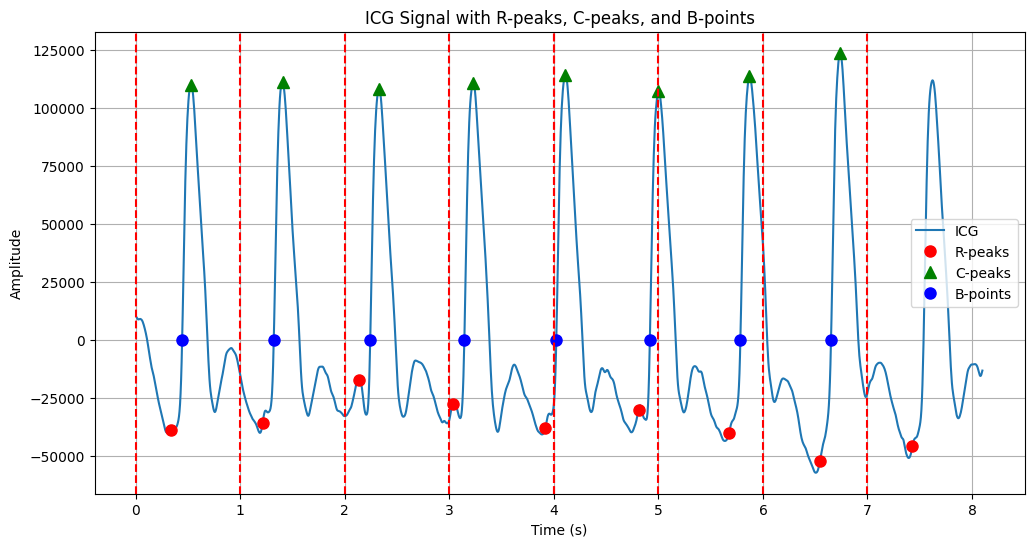

In [68]:
rpeaks_index = np.array([np.argmin(np.abs(icg_time - t)) for t in rpeaks_times])
plt.figure(figsize=(12, 6))
plt.plot(icg_time, icg_detrended, label='ICG')
plt.plot(icg_time[rpeaks_index], icg_detrended[rpeaks_index], 'ro', markersize=8, label='R-peaks')

# Plot C-peaks
plt.plot(C_peak_times, C_peaks_values, 'g^', markersize=8, label='C-peaks')

# Plot B points (zero-crossing points)
plt.plot(b_points, np.zeros_like(b_points), 'bo', markersize=8, label='B-points')  # Blue circles for B-points

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('ICG Signal with R-peaks, C-peaks, and B-points')
plt.legend()
plt.grid(True)

#obtain the avo info
avo_icg_all = measures[3,1]
avo_icg = avo_icg_all[0,0]
# avo_stc = measures[3,2] # avo_echo = measures[3,3] # avo_ppg = measures[3,4] #only the first one had more than 1 point
#print(avo_icg['data'])

#avc info
avc_icg_all = measures[5,1]
avc_icg = avc_icg_all[0,0]

fs_echo = 136
fs_icg = 200
for time_point in avo_icg['data']:
    plt.axvline(x=int(time_point), color='r', linestyle='--', label='AVO')
#for time_point in avc_icg['data']:
 #   plt.axvline(x=int(time_point), color='b', linestyle='--', label='AVC')

measures[4,1] -> ['PPEjec']
measures[4,2] -> ['PEP']
measures[4,3] -> ['PEP']
measures[4,4] -> ['PEP']

In [69]:
pep_1 = measures[4,1]
pep_2 = measures[4,2]
pep_3 = measures[4,3]
pep_4 = measures[4,4]

RB_interval = b_points-(rpeaks_values[:len(b_points)]) #if we assume Q occurs 20 ms before the R peak

print(RB_interval*1000)
print(pep_1['data'])
#print(pep_2['data']) #empty
#print(pep_3['data']) #empty
#print(pep_4['data']) #empty

[105.77312371 106.98293114 104.31845266 109.39742419 103.69504584
 108.49285445 109.38226876 106.39996232]
[[array([[100],
         [100],
         [105],
         [105],
         [ 95],
         [105],
         [105],
         [105],
         [100]], dtype=uint8)]]


We use the 15% above the baseline approach.

For this, we estimate the baseline again using SG, just like before

In [70]:
sg_window=301
sg_poly=2

baseline_det = savgol_filter(icg_detrended, window_length=sg_window, polyorder=sg_poly)
threshold_detrended = baseline_det * 1.15

# detect the first time point where the signal exceeds the threshold
b_point_15 = np.nan #initialize variable
for i in range(len(icg_detrended)):
    if icg_detrended[i] >= threshold_detrended[i]:
        b_point_15 = icg_time[i]  # Save the time when the signal exceeds the threshold
        break

print(f"The B point (15% above baseline) occurs at: {b_point_15} seconds")

The B point (15% above baseline) occurs at: 0.05060945713414 seconds


#### X point detection

The X-point detection is based on the observation that onset of steep rise in ICG towards the end of the T wave of ECG is closely aligned with the AVC. The lowest point in the first one-third of the C–C segment of the ICG is marked as the Xi point (initial estimate of X) and the highest point in the C–C interval is marked as the O point. The first difference of the ICG during the first half of the Xi–O segment is scanned for locating the points with a change of sign. Slopes of the line segments joining each of these points with the O point are calculated and the point with the highest slope is marked as the X point. An example of X-point detection is shown in figure 4.[11]

# AVO and AVC in ECHO

In this section we are going to plot AVO and AVC on top of the Echo signal to see if they match the opening and closure of the valves

1102
1609
     Correlation (r)       p-value
0          -0.056135  2.433842e-02
1          -0.074420  2.817414e-03
2           0.041214  9.841050e-02
3           0.070947  4.410203e-03
4           0.066695  7.446355e-03
..               ...           ...
268        -0.153174  6.580133e-10
269         0.100612  5.279364e-05
270        -0.063566  1.076066e-02
271        -0.089170  3.420619e-04
272        -0.117982  2.080722e-06

[273 rows x 2 columns]
Maximum r: 0.44308128368744776 at index 65 with p-value: 2.427494472173909e-78


<ipython-input-71-21c9f4268498>:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
<ipython-input-71-21c9f4268498>:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')
<ipython-input-71-21c9f4268498>:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='-

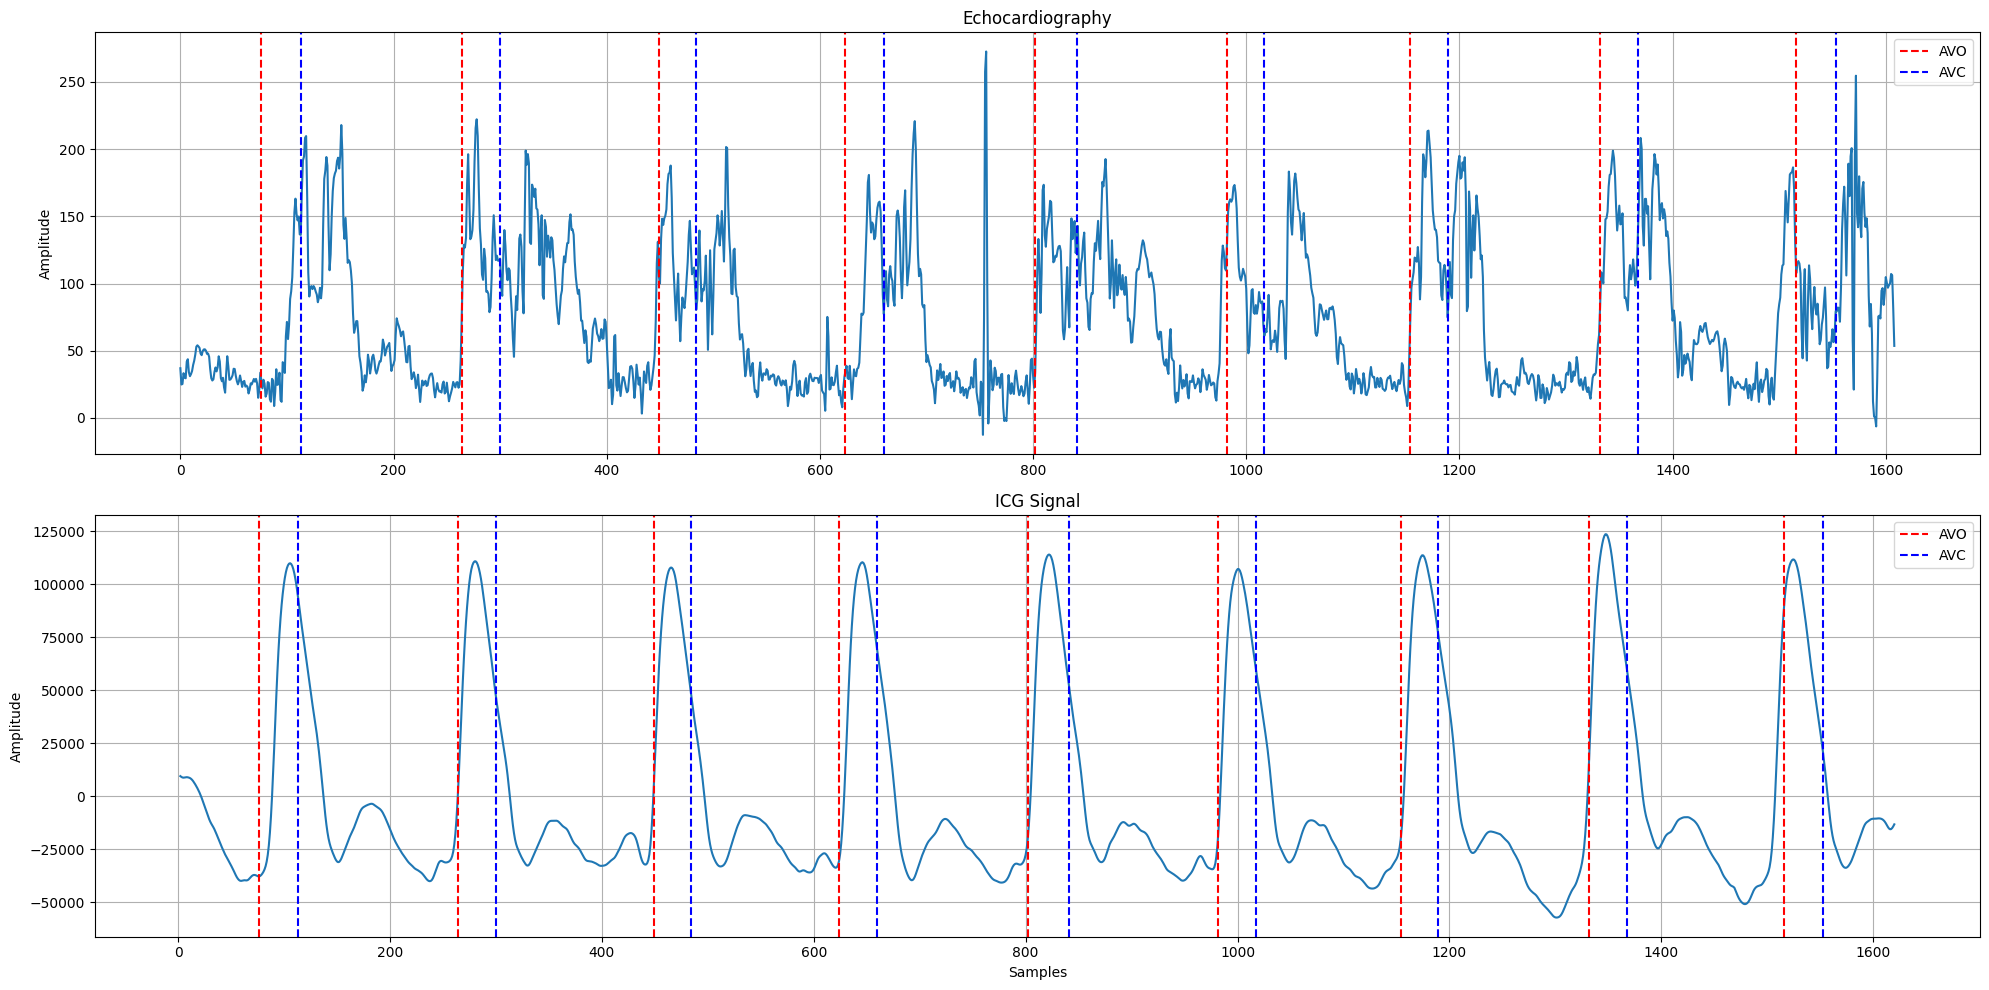

In [71]:
from scipy.stats import pearsonr
from scipy.signal import resample

#obtain the avo info
avo_icg_all = measures[3,1]
avo_icg = avo_icg_all[0,0]
# avo_stc = measures[3,2] # avo_echo = measures[3,3] # avo_ppg = measures[3,4] #only the first one had more than 1 point
#print(avo_icg['data'])

#avc info
avc_icg_all = measures[5,1]
avc_icg = avc_icg_all[0,0]

echo = measures[1,3]
echo_time = echo['time']
echo_data = echo['data']
echo_value = echo_data[0, 0]

# we obtain all the lines in echo
echo_all_lines = []
for i in range(0,273): #we know the depth is 273
    echo_line = echo_value[i, :, 0]
    echo_all_lines.append(echo_line)

echo_all_lines = np.array(echo_all_lines)

#we see that the length of echo and icg don't match because they have different fs
print(len(echo_all_lines[35]))
print(len(icg_detrended))

fs_echo = 136
fs_icg = 200

r_echo = []
p_echo = []
all_echo_resampled = []

for j in range(len(echo_all_lines)):
    echo_resampled = resample(echo_all_lines[j], len(icg_detrended)) #we resample the echo signal to the icg length
    r, p = pearsonr(icg_detrended, echo_resampled)
    r_echo.append(r)
    p_echo.append(p)
    all_echo_resampled.append(echo_resampled)

df = pd.DataFrame({
    'Correlation (r)': r_echo,
    'p-value': p_echo
})

print(df)

# we want to see the maximum correlation with the icg to select the most relevant line
max_r = max(r_echo)
max_index = r_echo.index(max_r)
corresponding_p = p_echo[max_index]

print(f"Maximum r: {max_r} at index {max_index} with p-value: {corresponding_p}")
# for 59146237/59146237_s0000002.mat --> Maximum r: 0.44308128368744776 at index 65 with p-value: 2.427494472173909e-78
# if we check the signal at 65 we see that it is the line with the most info (intuitively)
plt.figure(figsize=(20, 10))

plt.subplot(2, 1, 1)
plt.plot(all_echo_resampled[max_index])
plt.title('Echocardiography')
plt.ylabel('Amplitude')
plt.grid(True)

for time_point in avo_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')

#  legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.subplot(2, 1, 2)
plt.plot(icg_time * fs_icg, icg_detrended)
plt.title('ICG Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)

for time_point in avo_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='r', linestyle='--', label='AVO')
for time_point in avc_icg['data']:
    plt.axvline(x=int(time_point * fs_icg), color='b', linestyle='--', label='AVC')

#  legend without duplicates
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()